## Object-Oriented Programming & Statistical Properties of Data

---

# Part 1: Object-Oriented Programming (OOP)

## 1.1 Creating Your First Class

In [1]:
# Example 1: A simple class for laboratory samples

class Sample:
    """A class representing a laboratory sample."""
    
    def __init__(self, name, concentration, volume):
        """Initialize a new Sample object."""
        self.name = name              # Attribute: sample name
        self.concentration = concentration  # Attribute: in mol/L
        self.volume = volume          # Attribute: in mL
    
    def get_moles(self):
        """Calculate the number of moles in the sample."""
        return self.concentration * (self.volume / 1000)
    
    def dilute(self, factor):
        """Dilute the sample by a given factor."""
        self.concentration = self.concentration / factor
        print(f"{self.name} diluted. New concentration: {self.concentration:.4f} mol/L")
    
    def info(self):
        """Print information about the sample."""
        print(f"Sample: {self.name}")
        print(f"  Concentration: {self.concentration} mol/L")
        print(f"  Volume: {self.volume} mL")
        print(f"  Moles: {self.get_moles():.6f} mol")

In [2]:
# Creating objects (instances) of the Sample class
sample1 = Sample("Glucose", 0.5, 100)   # 0.5 M, 100 mL
sample2 = Sample("NaCl", 1.0, 50)       # 1.0 M, 50 mL

print("=== Sample 1 ===")
sample1.info()

print("\n=== Sample 2 ===")
sample2.info()

# Using methods
print(f"\nMoles in {sample1.name}: {sample1.get_moles()}")
sample1.dilute(2)  # Dilute by factor of 2

=== Sample 1 ===
Sample: Glucose
  Concentration: 0.5 mol/L
  Volume: 100 mL
  Moles: 0.050000 mol

=== Sample 2 ===
Sample: NaCl
  Concentration: 1.0 mol/L
  Volume: 50 mL
  Moles: 0.050000 mol

Moles in Glucose: 0.05
Glucose diluted. New concentration: 0.2500 mol/L


## 1.2 The Patient Class Example

In [3]:
class Patient:
    """A class representing a patient record."""
    
    def __init__(self, patient_id, name, age):
        self.patient_id = patient_id
        self.name = name
        self.age = age
        self.diagnoses = []
        self.treatments = []
        print(f"New patient record created: {self.patient_id} - {self.name}")
    
    def add_diagnosis(self, diagnosis, date):
        """Add a diagnosis to this patient's record."""
        self.diagnoses.append({"diagnosis": diagnosis, "date": date})
        print(f"Added diagnosis '{diagnosis}' for patient {self.name}")
    
    def get_summary(self):
        """Get a summary of this patient's record."""
        return (f"Patient: {self.name} (ID: {self.patient_id})\n"
                f"Age: {self.age}\n"
                f"Diagnoses: {len(self.diagnoses)}")

In [4]:
# Create and use patient objects
patient1 = Patient("P001", "John Doe", 45)
patient2 = Patient("P002", "Jane Smith", 32)

patient1.add_diagnosis("Hypertension", "2024-01-15")
patient1.add_diagnosis("Type 2 Diabetes", "2024-02-20")
patient2.add_diagnosis("Asthma", "2024-03-10")

print("\n=== Patient Summaries ===")
print(patient1.get_summary())
print()
print(patient2.get_summary())

New patient record created: P001 - John Doe
New patient record created: P002 - Jane Smith
Added diagnosis 'Hypertension' for patient John Doe
Added diagnosis 'Type 2 Diabetes' for patient John Doe
Added diagnosis 'Asthma' for patient Jane Smith

=== Patient Summaries ===
Patient: John Doe (ID: P001)
Age: 45
Diagnoses: 2

Patient: Jane Smith (ID: P002)
Age: 32
Diagnoses: 1


## 1.3 Inheritance

In [5]:
# Parent class (base class)
class Instrument:
    """Base class for laboratory instruments."""
    
    def __init__(self, name, manufacturer, serial_number):
        self.name = name
        self.manufacturer = manufacturer
        self.serial_number = serial_number
        self.is_calibrated = False
    
    def calibrate(self):
        """Calibrate the instrument."""
        from datetime import datetime
        self.is_calibrated = True
        print(f"{self.name} calibrated at {datetime.now()}")
    
    def get_status(self):
        """Get the current status of the instrument."""
        status = "Calibrated" if self.is_calibrated else "Needs calibration"
        return f"{self.name} ({self.manufacturer}): {status}"

In [6]:
# Child class - inherits from Instrument
class Spectrometer(Instrument):
    """A spectrometer class that inherits from Instrument."""
    
    def __init__(self, name, manufacturer, serial_number, wavelength_range):
        super().__init__(name, manufacturer, serial_number)  # Call parent's __init__
        self.wavelength_range = wavelength_range  # New attribute
        self.measurements = []
    
    def measure(self, sample_name, wavelength):
        """Take a measurement of a sample."""
        if not self.is_calibrated:
            print("Error: Instrument not calibrated.")
            return None
        
        import random
        absorbance = random.uniform(0.1, 2.0)
        result = {"sample": sample_name, "wavelength": wavelength, "absorbance": round(absorbance, 4)}
        self.measurements.append(result)
        print(f"Measured {sample_name} at {wavelength}nm: Abs = {result['absorbance']}")
        return result

In [7]:
# Using inheritance
uv_vis = Spectrometer("UV-Vis 2000", "LabCorp", "SN-12345", (200, 800))

print(uv_vis.get_status())  # Inherited method
uv_vis.measure("Sample A", 500)  # Try without calibration

uv_vis.calibrate()  # Inherited method
uv_vis.measure("Sample A", 500)  # Now it works
uv_vis.measure("Sample B", 650)

UV-Vis 2000 (LabCorp): Needs calibration
Error: Instrument not calibrated.
UV-Vis 2000 calibrated at 2026-01-29 15:43:26.900194
Measured Sample A at 500nm: Abs = 1.5115
Measured Sample B at 650nm: Abs = 0.1515


{'sample': 'Sample B', 'wavelength': 650, 'absorbance': 0.1515}

## 1.4 OOP Exercise

Create a `Molecule` class and a `Protein` class that inherits from it.

In [8]:
# SOLUTION: Molecule and Protein classes

class Molecule:
    """A class representing a chemical molecule."""
    
    def __init__(self, name, formula, molecular_weight):
        self.name = name
        self.formula = formula
        self.molecular_weight = molecular_weight
    
    def calculate_moles(self, mass):
        """Calculate moles from mass (g)."""
        return mass / self.molecular_weight


class Protein(Molecule):
    """A class representing a protein, inheriting from Molecule."""
    
    def __init__(self, name, formula, molecular_weight, amino_acids):
        super().__init__(name, formula, molecular_weight)
        self.amino_acids = amino_acids
    
    def get_length(self):
        """Return the number of amino acids."""
        return len(self.amino_acids)


# Test
water = Molecule("Water", "H2O", 18.015)
print(f"{water.name}: {water.formula}")
print(f"Moles in 36g of water: {water.calculate_moles(36):.2f} mol")

insulin_aa = ["Gly", "Ile", "Val", "Glu", "Gln", "Cys", "Cys", "Thr", "Ser", "Ile"]
insulin = Protein("Insulin", "C257H383N65O77S6", 5808, insulin_aa)
print(f"\n{insulin.name}: {insulin.get_length()} amino acids")

Water: H2O
Moles in 36g of water: 2.00 mol

Insulin: 10 amino acids


---
# Part 2: Statistical Properties of Data

In [9]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)  # For reproducibility

## 2.1 Measures of Central Tendency

In [10]:
# Sample data: patient ages
ages = np.array([25, 28, 32, 35, 35, 38, 42, 45, 48, 52, 55, 58, 35, 62])

print("Patient ages:", ages)
print(f"\nMean age: {np.mean(ages):.2f} years")
print(f"Median age: {np.median(ages):.2f} years")

mode_result = stats.mode(ages, keepdims=True)
print(f"Mode: {mode_result.mode[0]} years (appears {mode_result.count[0]} times)")

Patient ages: [25 28 32 35 35 38 42 45 48 52 55 58 35 62]

Mean age: 42.14 years
Median age: 40.00 years
Mode: 35 years (appears 3 times)


In [11]:
# Effect of outliers
print("=== Original Data ===")
print(f"Mean: {np.mean(ages):.2f}")
print(f"Median: {np.median(ages):.2f}")

ages_with_outlier = np.append(ages, 150)
print("\n=== With Outlier (150 years) ===")
print(f"Mean: {np.mean(ages_with_outlier):.2f}")
print(f"Median: {np.median(ages_with_outlier):.2f}")
print("\n→ Mean is sensitive to outliers, median is robust!")

=== Original Data ===
Mean: 42.14
Median: 40.00

=== With Outlier (150 years) ===
Mean: 49.33
Median: 42.00

→ Mean is sensitive to outliers, median is robust!


## 2.2 Measures of Variability

In [12]:
# Radiation dose measurements (in Gray)
doses = np.array([2.1, 2.3, 2.2, 2.5, 2.0, 2.4, 2.1, 2.6, 2.3, 2.2])

print("Radiation doses (Gy):", doses)
print(f"\nRange: {np.max(doses) - np.min(doses):.2f} Gy")
print(f"Variance: {np.var(doses, ddof=1):.4f} Gy²")
print(f"Standard Deviation: {np.std(doses, ddof=1):.4f} Gy")

q75, q25 = np.percentile(doses, [75, 25])
print(f"IQR: {q75 - q25:.2f} Gy (Q1={q25:.2f}, Q3={q75:.2f})")

Radiation doses (Gy): [2.1 2.3 2.2 2.5 2.  2.4 2.1 2.6 2.3 2.2]

Range: 0.60 Gy
Variance: 0.0357 Gy²
Standard Deviation: 0.1889 Gy
IQR: 0.25 Gy (Q1=2.12, Q3=2.38)


## 2.3 Probability Distributions

In [13]:
# Generate data from different distributions
n_samples = 10000

normal_data = np.random.normal(loc=50, scale=10, size=n_samples)     # Normal
poisson_data = np.random.poisson(lam=5, size=n_samples)              # Poisson
exponential_data = np.random.exponential(scale=5, size=n_samples)    # Exponential
binomial_data = np.random.binomial(n=100, p=0.3, size=n_samples)     # Binomial

print("Generated samples from 4 different distributions")

Generated samples from 4 different distributions


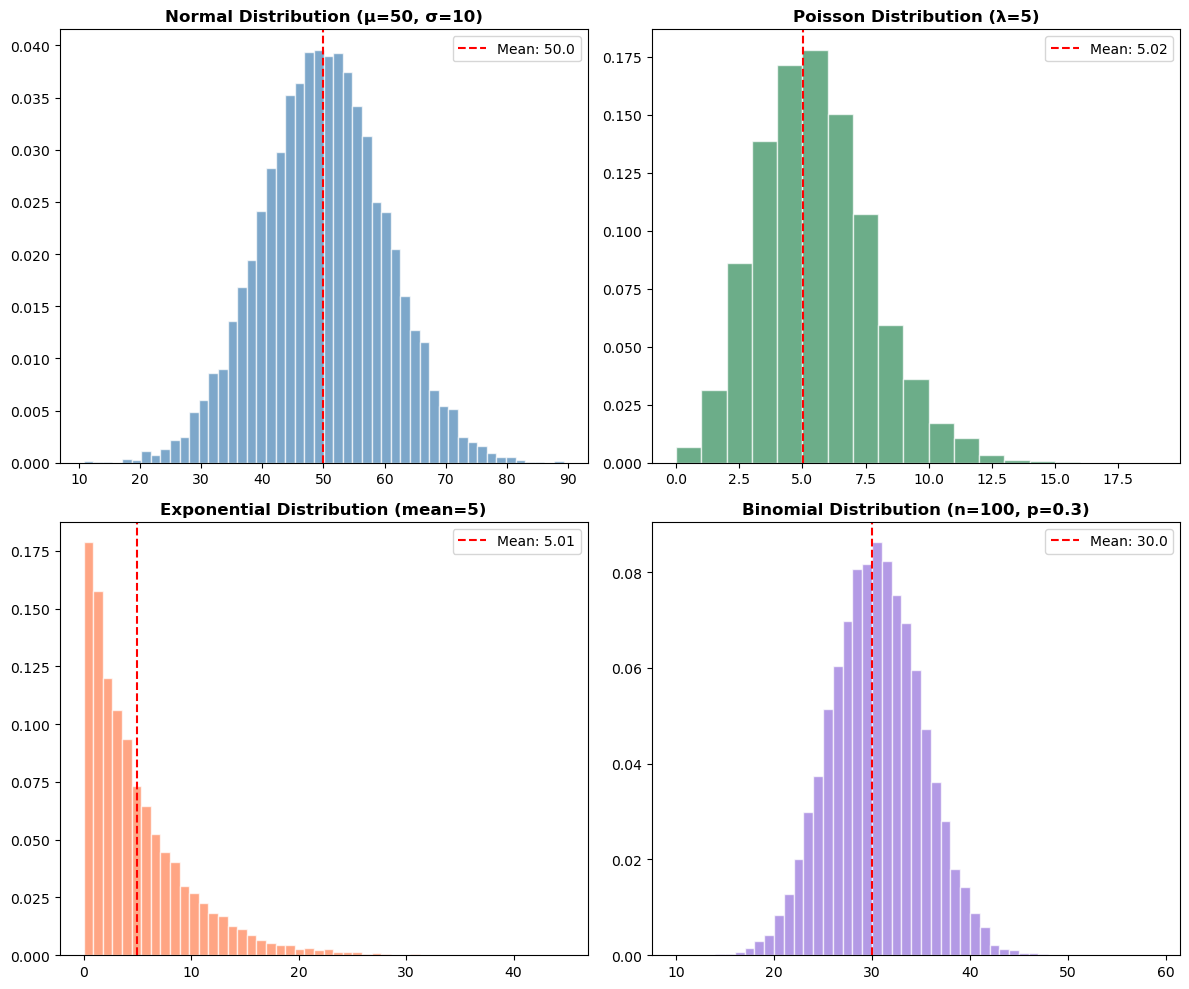

In [14]:
# Visualize distributions
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0, 0].hist(normal_data, bins=50, density=True, alpha=0.7, color='steelblue', edgecolor='white')
axes[0, 0].set_title('Normal Distribution (μ=50, σ=10)', fontweight='bold')
axes[0, 0].axvline(np.mean(normal_data), color='red', linestyle='--', label=f'Mean: {np.mean(normal_data):.1f}')
axes[0, 0].legend()

axes[0, 1].hist(poisson_data, bins=range(0, 20), density=True, alpha=0.7, color='seagreen', edgecolor='white')
axes[0, 1].set_title('Poisson Distribution (λ=5)', fontweight='bold')
axes[0, 1].axvline(np.mean(poisson_data), color='red', linestyle='--', label=f'Mean: {np.mean(poisson_data):.2f}')
axes[0, 1].legend()

axes[1, 0].hist(exponential_data, bins=50, density=True, alpha=0.7, color='coral', edgecolor='white')
axes[1, 0].set_title('Exponential Distribution (mean=5)', fontweight='bold')
axes[1, 0].axvline(np.mean(exponential_data), color='red', linestyle='--', label=f'Mean: {np.mean(exponential_data):.2f}')
axes[1, 0].legend()

axes[1, 1].hist(binomial_data, bins=range(10, 60), density=True, alpha=0.7, color='mediumpurple', edgecolor='white')
axes[1, 1].set_title('Binomial Distribution (n=100, p=0.3)', fontweight='bold')
axes[1, 1].axvline(np.mean(binomial_data), color='red', linestyle='--', label=f'Mean: {np.mean(binomial_data):.1f}')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

In [15]:
# Compare statistics
print("=" * 60)
print("COMPARISON OF DISTRIBUTION STATISTICS")
print("=" * 60)

distributions = [
    ("Normal (μ=50, σ=10)", normal_data),
    ("Poisson (λ=5)", poisson_data),
    ("Exponential (mean=5)", exponential_data),
    ("Binomial (n=100, p=0.3)", binomial_data)
]

print(f"{'Distribution':<25} {'Mean':>10} {'Std Dev':>10} {'Median':>10} {'Skewness':>10}")
print("-" * 65)

for name, data in distributions:
    print(f"{name:<25} {np.mean(data):>10.2f} {np.std(data):>10.2f} {np.median(data):>10.2f} {stats.skew(data):>10.2f}")

COMPARISON OF DISTRIBUTION STATISTICS
Distribution                    Mean    Std Dev     Median   Skewness
-----------------------------------------------------------------
Normal (μ=50, σ=10)            49.98      10.03      49.97       0.00
Poisson (λ=5)                   5.02       2.25       5.00       0.49
Exponential (mean=5)            5.01       4.92       3.55       1.96
Binomial (n=100, p=0.3)        29.97       4.64      30.00       0.07


## 2.4 The Normal Distribution (Gaussian)

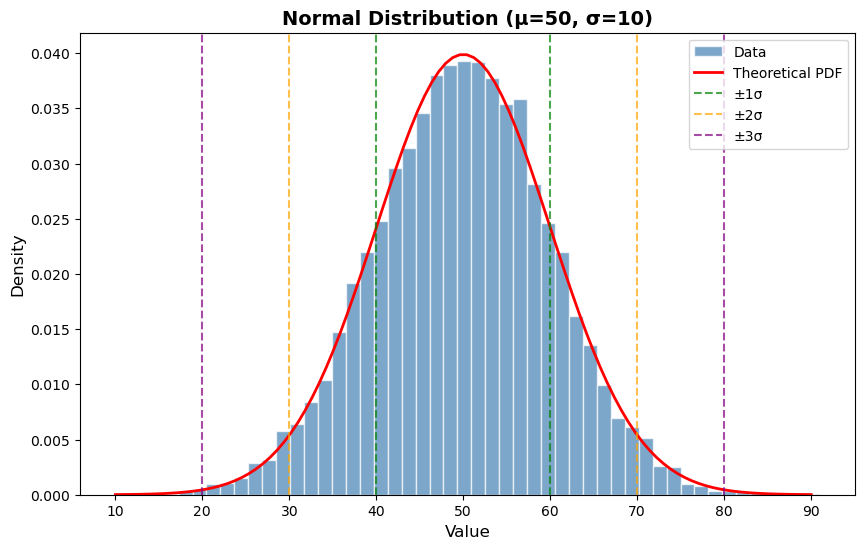


68-95-99.7 Rule Verification:
  Within 1σ: 68.0%
  Within 2σ: 95.0%
  Within 3σ: 99.6%


In [16]:
# Generate normal data and fit PDF
mean, sigma = 50, 10
data = np.random.normal(mean, sigma, 10000)

# Create histogram
fig, ax = plt.subplots(figsize=(10, 6))
counts, bins, _ = ax.hist(data, bins=50, density=True, alpha=0.7, color='steelblue', edgecolor='white', label='Data')

# Plot theoretical PDF
x = np.linspace(mean - 4*sigma, mean + 4*sigma, 100)
pdf = 1/(sigma * np.sqrt(2*np.pi)) * np.exp(-(x-mean)**2 / (2*sigma**2))
ax.plot(x, pdf, 'r-', linewidth=2, label='Theoretical PDF')

# Mark standard deviations
for i, color in zip([1, 2, 3], ['green', 'orange', 'purple']):
    ax.axvline(mean + i*sigma, color=color, linestyle='--', alpha=0.7)
    ax.axvline(mean - i*sigma, color=color, linestyle='--', alpha=0.7, label=f'±{i}σ')

ax.set_xlabel('Value', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title(f'Normal Distribution (μ={mean}, σ={sigma})', fontsize=14, fontweight='bold')
ax.legend()
plt.show()

# Print percentages within each SD
print("\n68-95-99.7 Rule Verification:")
for n_sd in [1, 2, 3]:
    within = np.sum((data >= mean - n_sd*sigma) & (data <= mean + n_sd*sigma)) / len(data) * 100
    print(f"  Within {n_sd}σ: {within:.1f}%")

## 2.5 Comparing Normal, Poisson, and Binomial

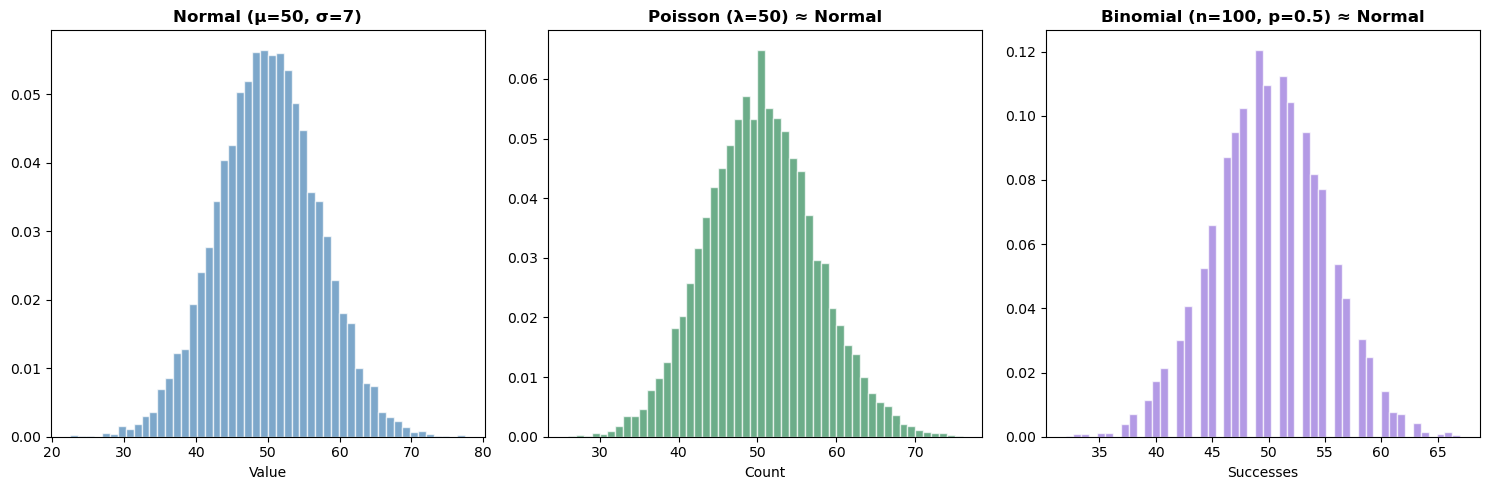

Key insight: For large parameters, Poisson and Binomial approximate Normal!
  Poisson λ=50: Mean=49.9, Std=7.0
  Binomial n=100, p=0.5: Mean=50.0, Std=5.0


In [17]:
# Important comparison: When Poisson and Binomial approximate Normal
np.random.seed(42)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 1. Normal distribution
normal = np.random.normal(50, 7, 10000)
axes[0].hist(normal, bins=50, density=True, alpha=0.7, color='steelblue', edgecolor='white')
axes[0].set_title('Normal (μ=50, σ=7)', fontweight='bold')
axes[0].set_xlabel('Value')

# 2. Poisson with large λ (approximates Normal)
poisson_large = np.random.poisson(50, 10000)
axes[1].hist(poisson_large, bins=50, density=True, alpha=0.7, color='seagreen', edgecolor='white')
axes[1].set_title('Poisson (λ=50) ≈ Normal', fontweight='bold')
axes[1].set_xlabel('Count')

# 3. Binomial with large n (approximates Normal)
binomial_large = np.random.binomial(100, 0.5, 10000)
axes[2].hist(binomial_large, bins=50, density=True, alpha=0.7, color='mediumpurple', edgecolor='white')
axes[2].set_title('Binomial (n=100, p=0.5) ≈ Normal', fontweight='bold')
axes[2].set_xlabel('Successes')

plt.tight_layout()
plt.show()

print("Key insight: For large parameters, Poisson and Binomial approximate Normal!")
print(f"  Poisson λ=50: Mean={np.mean(poisson_large):.1f}, Std={np.std(poisson_large):.1f}")
print(f"  Binomial n=100, p=0.5: Mean={np.mean(binomial_large):.1f}, Std={np.std(binomial_large):.1f}")

## 2.6 Hypothesis Testing: T-test Example

In [18]:
# Scenario: Testing if a new drug reduces blood pressure
np.random.seed(42)

control = np.array([5, 3, 4, 6, 2, 4, 3, 5, 4, 3])      # Placebo group
treatment = np.array([8, 9, 7, 10, 8, 9, 11, 8, 9, 10]) # Drug group

print("=== Blood Pressure Reduction Study ===")
print(f"Control group (placebo): mean = {np.mean(control):.2f} mmHg")
print(f"Treatment group (drug):  mean = {np.mean(treatment):.2f} mmHg")

# Independent samples t-test
t_stat, p_value = stats.ttest_ind(treatment, control)

print(f"\nT-statistic: {t_stat:.3f}")
print(f"P-value: {p_value:.6f}")

# Decision
alpha = 0.05
print(f"\nDecision (α = {alpha}):")
if p_value < alpha:
    print(f"  → Reject H₀: Significant difference between groups!")
    print(f"  → The drug appears to have an effect.")
else:
    print(f"  → Fail to reject H₀: No significant difference")

=== Blood Pressure Reduction Study ===
Control group (placebo): mean = 3.90 mmHg
Treatment group (drug):  mean = 8.90 mmHg

T-statistic: 9.339
P-value: 0.000000

Decision (α = 0.05):
  → Reject H₀: Significant difference between groups!
  → The drug appears to have an effect.


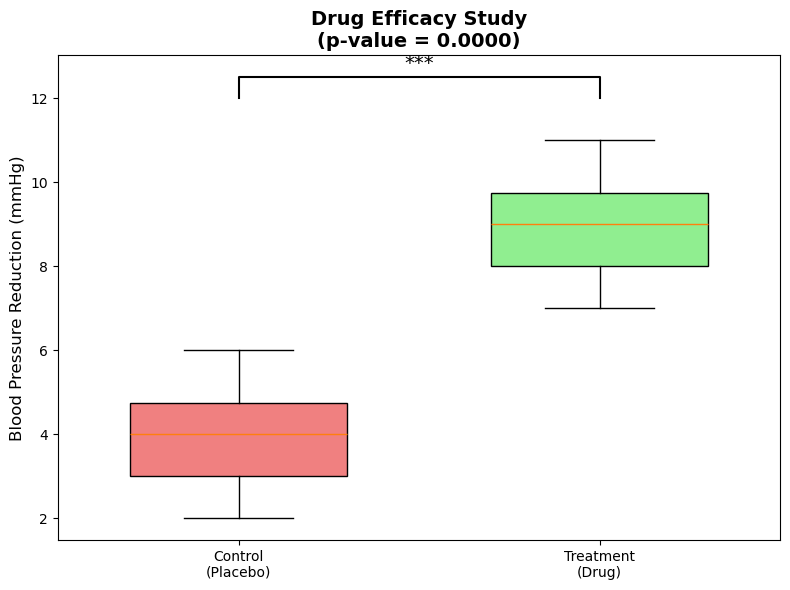

In [19]:
# Visualize the comparison
fig, ax = plt.subplots(figsize=(8, 6))

positions = [1, 2]
bp = ax.boxplot([control, treatment], positions=positions, widths=0.6, patch_artist=True)

colors = ['lightcoral', 'lightgreen']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

ax.set_xticklabels(['Control\n(Placebo)', 'Treatment\n(Drug)'])
ax.set_ylabel('Blood Pressure Reduction (mmHg)', fontsize=12)
ax.set_title(f'Drug Efficacy Study\n(p-value = {p_value:.4f})', fontsize=14, fontweight='bold')

# Add significance annotation
if p_value < 0.001:
    sig_text = '***'
elif p_value < 0.01:
    sig_text = '**'
elif p_value < 0.05:
    sig_text = '*'
else:
    sig_text = 'ns'

y_max = max(max(control), max(treatment)) + 1
ax.plot([1, 1, 2, 2], [y_max, y_max+0.5, y_max+0.5, y_max], 'k-')
ax.text(1.5, y_max+0.7, sig_text, ha='center', fontsize=14)

plt.tight_layout()
plt.show()

## 2.7 Statistics Exercise

=== Descriptive Statistics ===
Mean: 99.41
Median: 99.38
Standard Deviation: 15.02
Variance: 225.58
Range: 102.04
IQR: 20.30


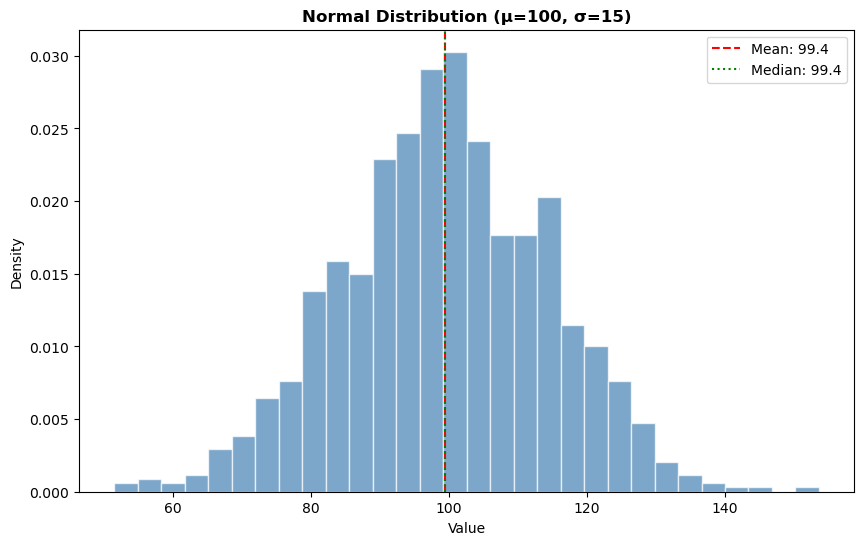


Normality Test: p-value = 0.9298
Data is likely normally distributed


In [20]:
# EXERCISE: Complete the analysis
# Generate 1000 random samples from a normal distribution with mean=100 and std=15
# Calculate descriptive statistics and create a histogram

np.random.seed(123)

# YOUR CODE HERE:
# 1. Generate the data
data = np.random.normal(100, 15, 1000)

# 2. Calculate statistics
print("=== Descriptive Statistics ===")
print(f"Mean: {np.mean(data):.2f}")
print(f"Median: {np.median(data):.2f}")
print(f"Standard Deviation: {np.std(data, ddof=1):.2f}")
print(f"Variance: {np.var(data, ddof=1):.2f}")
print(f"Range: {np.max(data) - np.min(data):.2f}")

q75, q25 = np.percentile(data, [75, 25])
print(f"IQR: {q75 - q25:.2f}")

# 3. Create histogram
plt.figure(figsize=(10, 6))
plt.hist(data, bins=30, density=True, alpha=0.7, color='steelblue', edgecolor='white')
plt.axvline(np.mean(data), color='red', linestyle='--', label=f'Mean: {np.mean(data):.1f}')
plt.axvline(np.median(data), color='green', linestyle=':', label=f'Median: {np.median(data):.1f}')
plt.xlabel('Value')
plt.ylabel('Density')
plt.title('Normal Distribution (μ=100, σ=15)', fontweight='bold')
plt.legend()
plt.show()

# 4. Test for normality
stat, p_value = stats.normaltest(data)
print(f"\nNormality Test: p-value = {p_value:.4f}")
print(f"Data is {'likely' if p_value > 0.05 else 'unlikely'} normally distributed")

---
# Summary

## Object-Oriented Programming
- **Classes** are blueprints; **objects** are instances
- `__init__` initializes object attributes
- `self` refers to the current object
- **Inheritance** allows code reuse and extension

## Statistical Properties
- **Central tendency**: mean, median, mode
- **Variability**: range, variance, standard deviation, IQR
- **Distributions**: Normal, Poisson, Binomial, Exponential
- **Hypothesis testing**: T-tests, p-values, significance

## Key Python Libraries
- `numpy`: numerical operations
- `scipy.stats`: statistical functions
- `matplotlib`: visualization